In [ ]:
'''# ✅ Install the correct BayesFlow version (clean install)

!pip install --upgrade pip setuptools wheel
!pip install bayesflow==2.0.5 --quiet
!pip install numpy
!pip install numpy scipy --upgrade --force-reinstall
'''

In [11]:
!pip install --upgrade pip setuptools wheel
!pip install bayesflow==2.0.5 --quiet
!pip install numpy
!pip install numpy scipy --upgrade --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [bayesflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 147.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 49.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]
ERROR: pip's dependency 

In [ ]:
'''!pip uninstall numpy scipy -y
!pip install numpy scipy --upgrade --force-reinstall'''

'!pip uninstall numpy scipy -y\n!pip install numpy scipy --upgrade --force-reinstall'

**STEP 1: Final Version — 3-Body Simulator with Noise and Random Masses**

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# -----------------------------------------------
# Constants and Physics
# -----------------------------------------------
G = 1.0  # Gravitational constant for simulation

def three_body_equations(t, y, masses):
    positions = y[:6].reshape(3, 2)
    velocities = y[6:].reshape(3, 2)
    dydt = np.zeros_like(y)
    dydt[:6] = velocities.flatten()

    for i in range(3):
        force = np.zeros(2)
        for j in range(3):
            if i != j:
                r = positions[j] - positions[i]
                distance = np.linalg.norm(r) + 1e-5  # epsilon to avoid divide-by-zero
                force += G * masses[j] * r / distance**3
        dydt[6 + 2*i : 6 + 2*i + 2] = force
    return dydt

def simulate_3body(initial_positions, initial_velocities, masses, t_span=(0, 5), t_eval=None):
    y0 = np.hstack((initial_positions.flatten(), initial_velocities.flatten()))
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 100)
    result = solve_ivp(fun=lambda t, y: three_body_equations(t, y, masses),
                       t_span=t_span, y0=y0, t_eval=t_eval, rtol=1e-9)
    return result.t, result.y

# -----------------------------------------------
# Data Sampling Utilities
# -----------------------------------------------
def sample_initial_conditions():
    # Random positions and velocities
    initial_positions = np.random.uniform(-1, 1, size=(3, 2))
    initial_velocities = np.random.uniform(-1, 1, size=(3, 2))

    # FIXED masses
    masses = np.random.uniform(0.5, 2.0, size=(3,))
    return initial_positions, initial_velocities, masses


def generate_single_simulation(t_span=(0, 5), t_eval=None, noise_std=0.05):
    init_pos, init_vel, masses = sample_initial_conditions()
    times, states = simulate_3body(init_pos, init_vel, masses, t_span=t_span, t_eval=t_eval)

    final_state = states[:, -1]  # [x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3]
    noisy_final_state = final_state + np.random.normal(0, noise_std, size=final_state.shape)

    initial_params = np.hstack((init_pos.flatten(), init_vel.flatten()))
    return initial_params, noisy_final_state, masses

# -----------------------------------------------
# Quick Test Visualization
# -----------------------------------------------
def plot_trajectory(states):
    positions = states[:6].reshape(3, 2, -1)
    plt.figure(figsize=(6, 6))
    for i in range(3):
        plt.plot(positions[i, 0], positions[i, 1], label=f'Body {i+1}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('3-Body Trajectories')
    plt.legend()
    plt.grid()
    plt.axis('equal')
    plt.show()




Initial Conditions (x, y, vx, vy for 3 bodies):
[ 0.50761024  0.0256516  -0.16712274  0.5566469  -0.61005061  0.29759053
  0.364388   -0.95766779 -0.71730597 -0.71119108 -0.35166564  0.75432008]

Noisy Final Observation (used as input to inference model):
[-0.13570483  0.63720232 -2.65333654  0.7444698  -2.2551269   0.56593269
  1.21769912 -0.21878805  0.24920566  1.32056216 -1.20301708 -0.51988967]

fixed Masses:
[0.55768327 1.0724308  1.99021004]


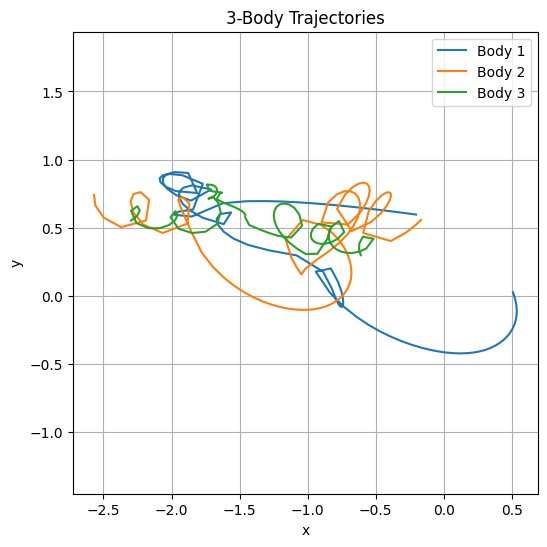

In [10]:
# -----------------------------------------------
# Run a Test
# -----------------------------------------------
# Test run: one simulation
init_params, noisy_final, masses = generate_single_simulation()
print("Initial Conditions (x, y, vx, vy for 3 bodies):")
print(init_params)
print("\nNoisy Final Observation (used as input to inference model):")
print(noisy_final)
print("\nfixed Masses:")
print(masses)

# Plot the trajectory (optional)
_, states = simulate_3body(init_params[:6].reshape(3, 2),
                           init_params[6:].reshape(3, 2),
                           masses)
plot_trajectory(states)

**STEP 2: Generate Synthetic Dataset for Training**

In [ ]:
# --------------------------------------------
# Parameters
# --------------------------------------------
NUM_SAMPLES = 10000     # Use 100 for fast testing
USE_FULL_TRAJECTORY = True  # Full trajectory mode enabled
NOISE_STD = 0.05

# --------------------------------------------
# Arrays to hold data
# --------------------------------------------
X = []  # full trajectories (observables)
Y = []  # true initial conditions (targets)

# --------------------------------------------
# Loop over simulations
# --------------------------------------------
for i in range(NUM_SAMPLES):

    # Sample initial positions and velocities and masses
    init_pos = np.random.uniform(-1, 1, size=(3, 2))
    init_vel = np.random.uniform(-1, 1, size=(3, 2))
    masses = np.random.uniform(0.5, 2.0, size=(3,))

    # Simulate full trajectory
    states = simulate_3body(init_pos, init_vel, masses)[1]  # shape: (time_steps, 12)

    # Add Gaussian noise to entire trajectory
    noisy_states = states + np.random.normal(0, NOISE_STD, size=states.shape)

    # Flatten initial conditions to 12-dim vector (x1, y1, x2, y2, ..., vx3, vy3)
    init_params = np.concatenate([init_pos.flatten(), init_vel.flatten()])

    # Append to dataset
    X.append(noisy_states)   # input to inference model
    Y.append(init_params)    # true parameters

    if i % 1000 == 0:
      np.savez(f"three_body_dataset_full_trajectory_{i}.npz", X=X, Y=Y)
      print(f"✅ Dataset saved as 'three_body_dataset_full_trajectory_{i}.npz'")

# Convert lists to arrays
X = np.array(X)  # shape: (samples, time_steps, 12)
Y = np.array(Y)  # shape: (samples, 12)

# Print summary
print("\n✅ Dataset generation complete.")
print("X shape (trajectories):", X.shape)
print("Y shape (initial conditions):", Y.shape)


# Save to file
np.savez("three_body_dataset_full_trajectory_10000_main.npz", X=X, Y=Y)
print("✅ Dataset saved as 'three_body_dataset_full_trajectory.npz'")
while True:
  xxx = 1

✅ Dataset saved as 'three_body_dataset_full_trajectory_0.npz'
✅ Dataset saved as 'three_body_dataset_full_trajectory_1000.npz'
✅ Dataset saved as 'three_body_dataset_full_trajectory_2000.npz'
✅ Dataset saved as 'three_body_dataset_full_trajectory_3000.npz'
✅ Dataset saved as 'three_body_dataset_full_trajectory_4000.npz'
✅ Dataset saved as 'three_body_dataset_full_trajectory_5000.npz'
✅ Dataset saved as 'three_body_dataset_full_trajectory_6000.npz'
✅ Dataset saved as 'three_body_dataset_full_trajectory_7000.npz'
✅ Dataset saved as 'three_body_dataset_full_trajectory_8000.npz'
✅ Dataset saved as 'three_body_dataset_full_trajectory_9000.npz'

✅ Dataset generation complete.
X shape (trajectories): (10000, 12, 100)
Y shape (initial conditions): (10000, 12)
✅ Dataset saved as 'three_body_dataset_full_trajectory.npz'


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
"""
# Show example pair
i = 0  # pick any index
print("X (noisy final observation):", X[i])
print("Y (true initial conditions):", Y[i])
"""


In [ ]:
"""
# Combine X and Y into a single array for CSV
XY_combined = np.hstack((X, Y))  # shape (1000, 24)

# Define column names
columns = [f"obs_{i}" for i in range(12)] + [f"init_{i}" for i in range(12)]

# Save to CSV using pandas
import pandas as pd

df = pd.DataFrame(XY_combined, columns=columns)
df.to_csv("three_body_dataset_final_state.csv", index=False)

print("✅ Dataset saved as 'three_body_dataset_final_state.csv'")
"""

**🔄 Optional: Load the Dataset Later**

In [ ]:
"""

# Load the full dataset
data = np.load("three_body_dataset_final_state.npz")
X = data["X"]
Y = data["Y"]
print("Loaded X shape:", X.shape)
print("Loaded Y shape:", Y.shape)


######################

data = np.load("three_body_dataset_final_state.npz")
X = data["X"][:100]  # Take only the first 100 samples
Y = data["Y"][:100]  # Take only the first 100 samples

print("Loaded X shape:", X.shape)
print("Loaded Y shape:", Y.shape)

"""

**Step 3: Train a BayesFlow Model**

**1. Install BayesFlow**

In [ ]:
'''!pip install bayesflow --quiet
'''

**2. Load Your Dataset**

In [1]:
import numpy as np

# Load full trajectory dataset
data = np.load("three_body_dataset_full_trajectory_10000_main.npz")
X = data["X"]     # shape (samples, time_steps, 12)
Y = data["Y"]     # shape (samples, 12)

print("✅ Data loaded:")
print("X shape (observations):", X.shape)
print("Y shape (parameters):", Y.shape)


✅ Data loaded:
X shape (observations): (10000, 12, 100)
Y shape (parameters): (10000, 12)


**3. Reshape Trajectory to Match TimeSeriesTransformer Format**

BayesFlow expects:

observables: shape (samples, time_steps, features)

parameters: shape (samples, param_dim)

In our case:

features = 12 (x, y, vx, vy for 3 bodies)

time_steps = 100 (but yours is transposed — we'll fix that)

In [2]:
# Fix shape: currently (samples, features, time_steps)
# Convert to (samples, time_steps, features)
X = np.transpose(X, (0, 2, 1))  # Now shape is (100, 100, 12)
print("✅ Reshaped X:", X.shape)


✅ Reshaped X: (10000, 100, 12)


**4. Wrap in BayesFlow-Compatible Dict**

In [4]:
dataset = [{"observables": X[i], "parameters": Y[i]} for i in range(len(X))]

**5. Define and Train the BayesFlow Model** **bold text**

In [5]:
import bayesflow as bf

# Create dict of full dataset
full_data = {
    "observables": X,
    "parameters": Y
}

# ✅ Manual split
from sklearn.model_selection import train_test_split

train_obs, val_obs, train_params, val_params = train_test_split(
    X, Y, test_size=0.1, random_state=42
)

train_data = {
    "observables": train_obs,
    "parameters": train_params
}

val_data = {
    "observables": val_obs,
    "parameters": val_params
}

# ✅ Define the workflow
workflow = bf.BasicWorkflow(
    inference_network=bf.networks.FlowMatching(),
    summary_network=bf.networks.TimeSeriesTransformer(),
    inference_variables=["parameters"],
    summary_variables=["observables"]
)

# ✅ Train using manual validation data
history = workflow.fit_offline(
    train_data,
    validation_data=val_data,
    epochs=50,
    batch_size=16
)

print("✅ Model training completed.")


INFO:bayesflow:Using backend 'tensorflow'
INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 134s 206ms/step - loss: 3.6110 - val_loss: 1.6093
Epoch 2/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 117s 208ms/step - loss: 1.3504 - val_loss: 0.7671
Epoch 3/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 114s 202ms/step - loss: 0.7755 - val_loss: 0.5363
Epoch 4/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 112s 199ms/step - loss: 0.5875 - val_loss: 0.4285
Epoch 5/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 112s 199ms/step - loss: 0.5035 - val_loss: 0.4059
Epoch 6/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 140s 195ms/step - loss: 0.4411 - val_loss: 0.3540
Epoch 7/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 140s 192ms/step - loss: 0.4227 - val_loss: 0.3543
Epoch 8/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 110s 195ms/step - loss: 0.3911 - val_loss: 0.3328
Epoch 9/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 108s 191ms/step - loss: 0.3517 - val_loss: 0.3092
Epoch 10/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 110s 196ms/step - loss: 0.3419 - val_loss: 0.2986
Epoch 11/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 108s 193ms/step - loss: 0.3252 - val_loss: 0.2979
Epoch 12

**6. Plot Training Diagnostics**

{'losses': <Figure size 1600x400 with 1 Axes>,
 'recovery': <Figure size 3000x1000 with 12 Axes>,
 'calibration_ecdf': <Figure size 3000x1000 with 12 Axes>,
 'z_score_contraction': <Figure size 3000x1000 with 12 Axes>}

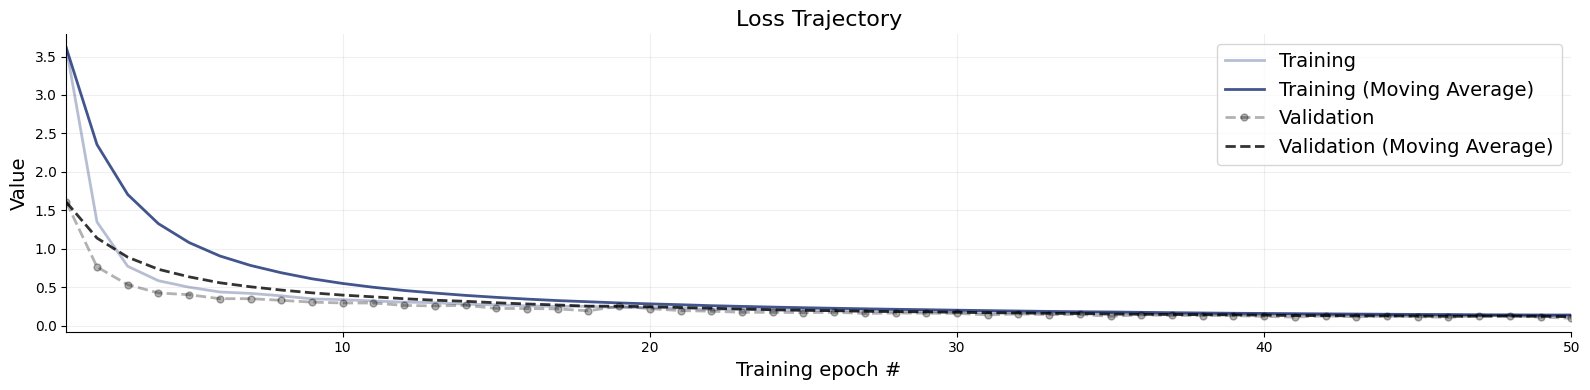

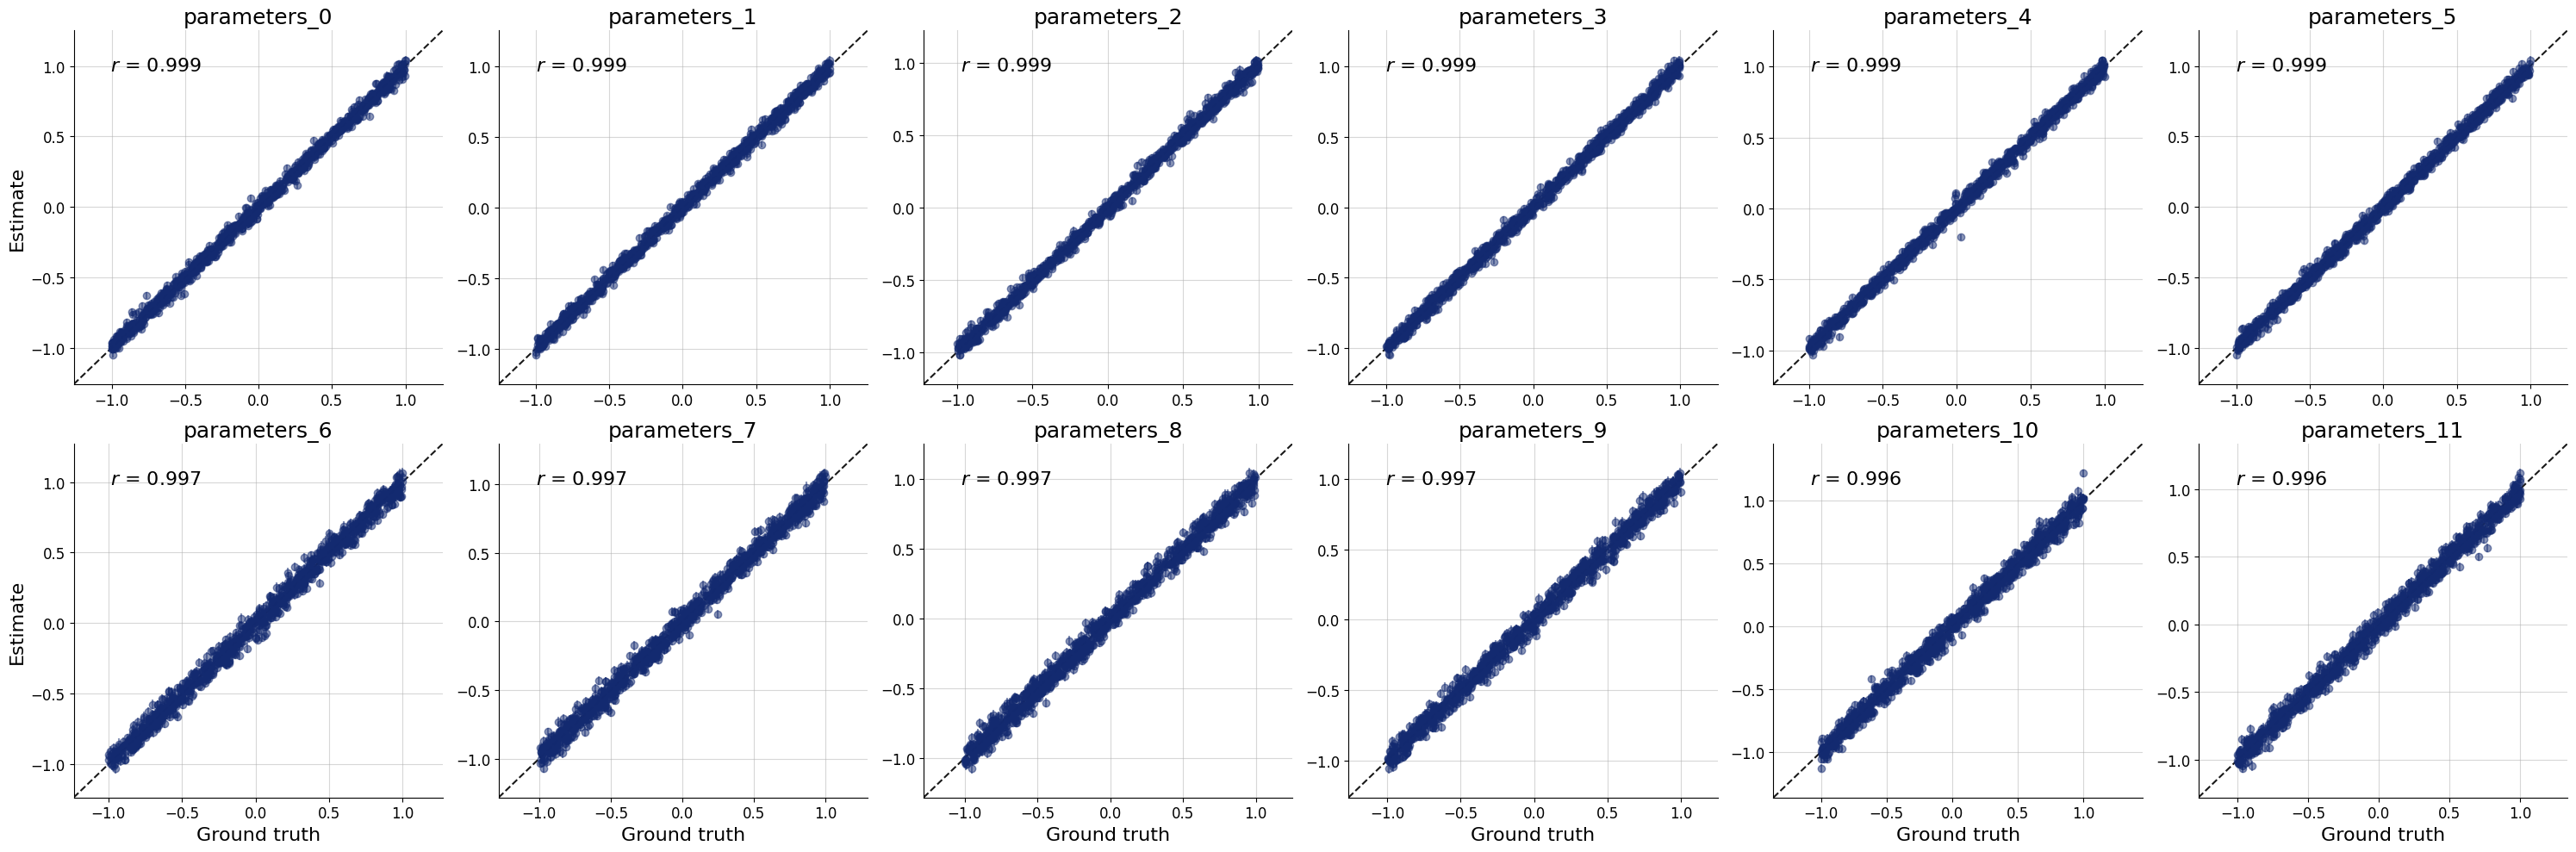

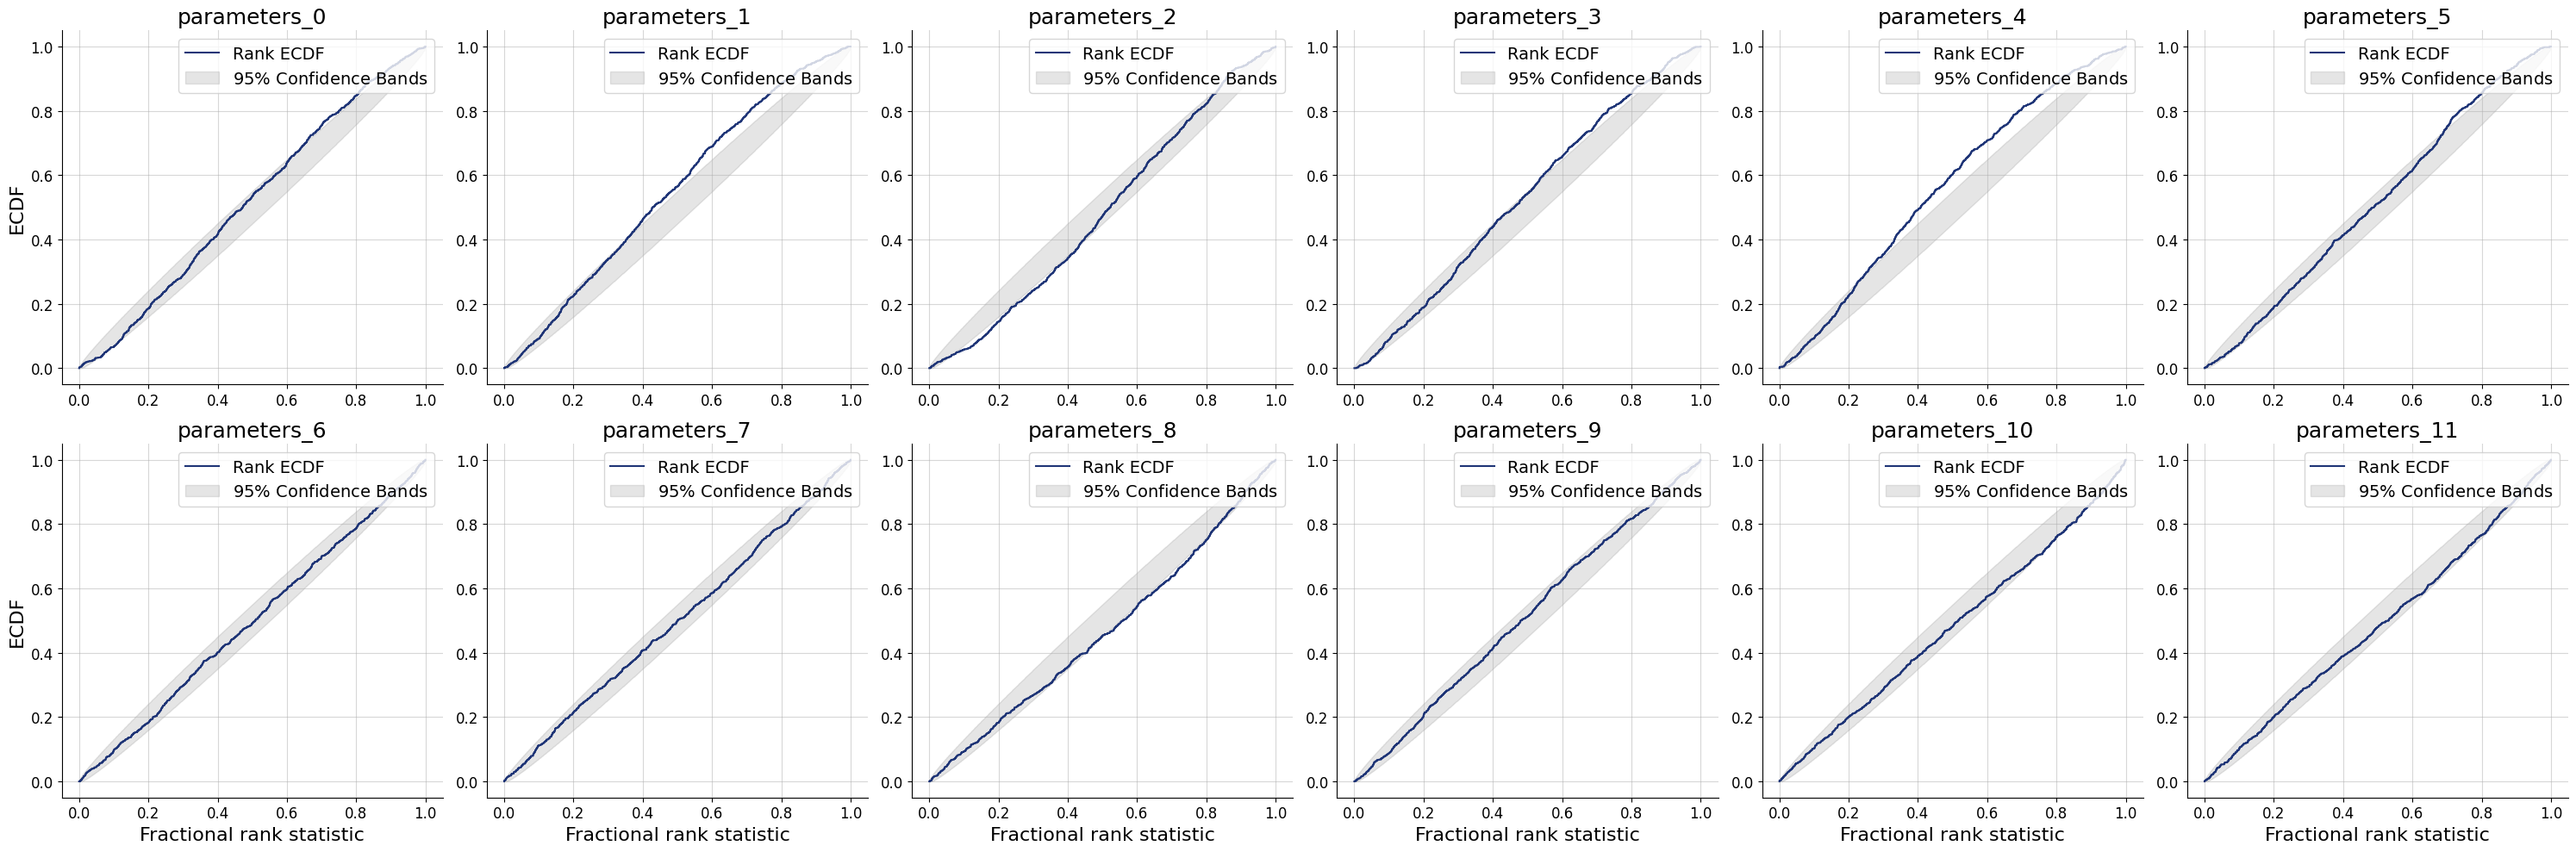

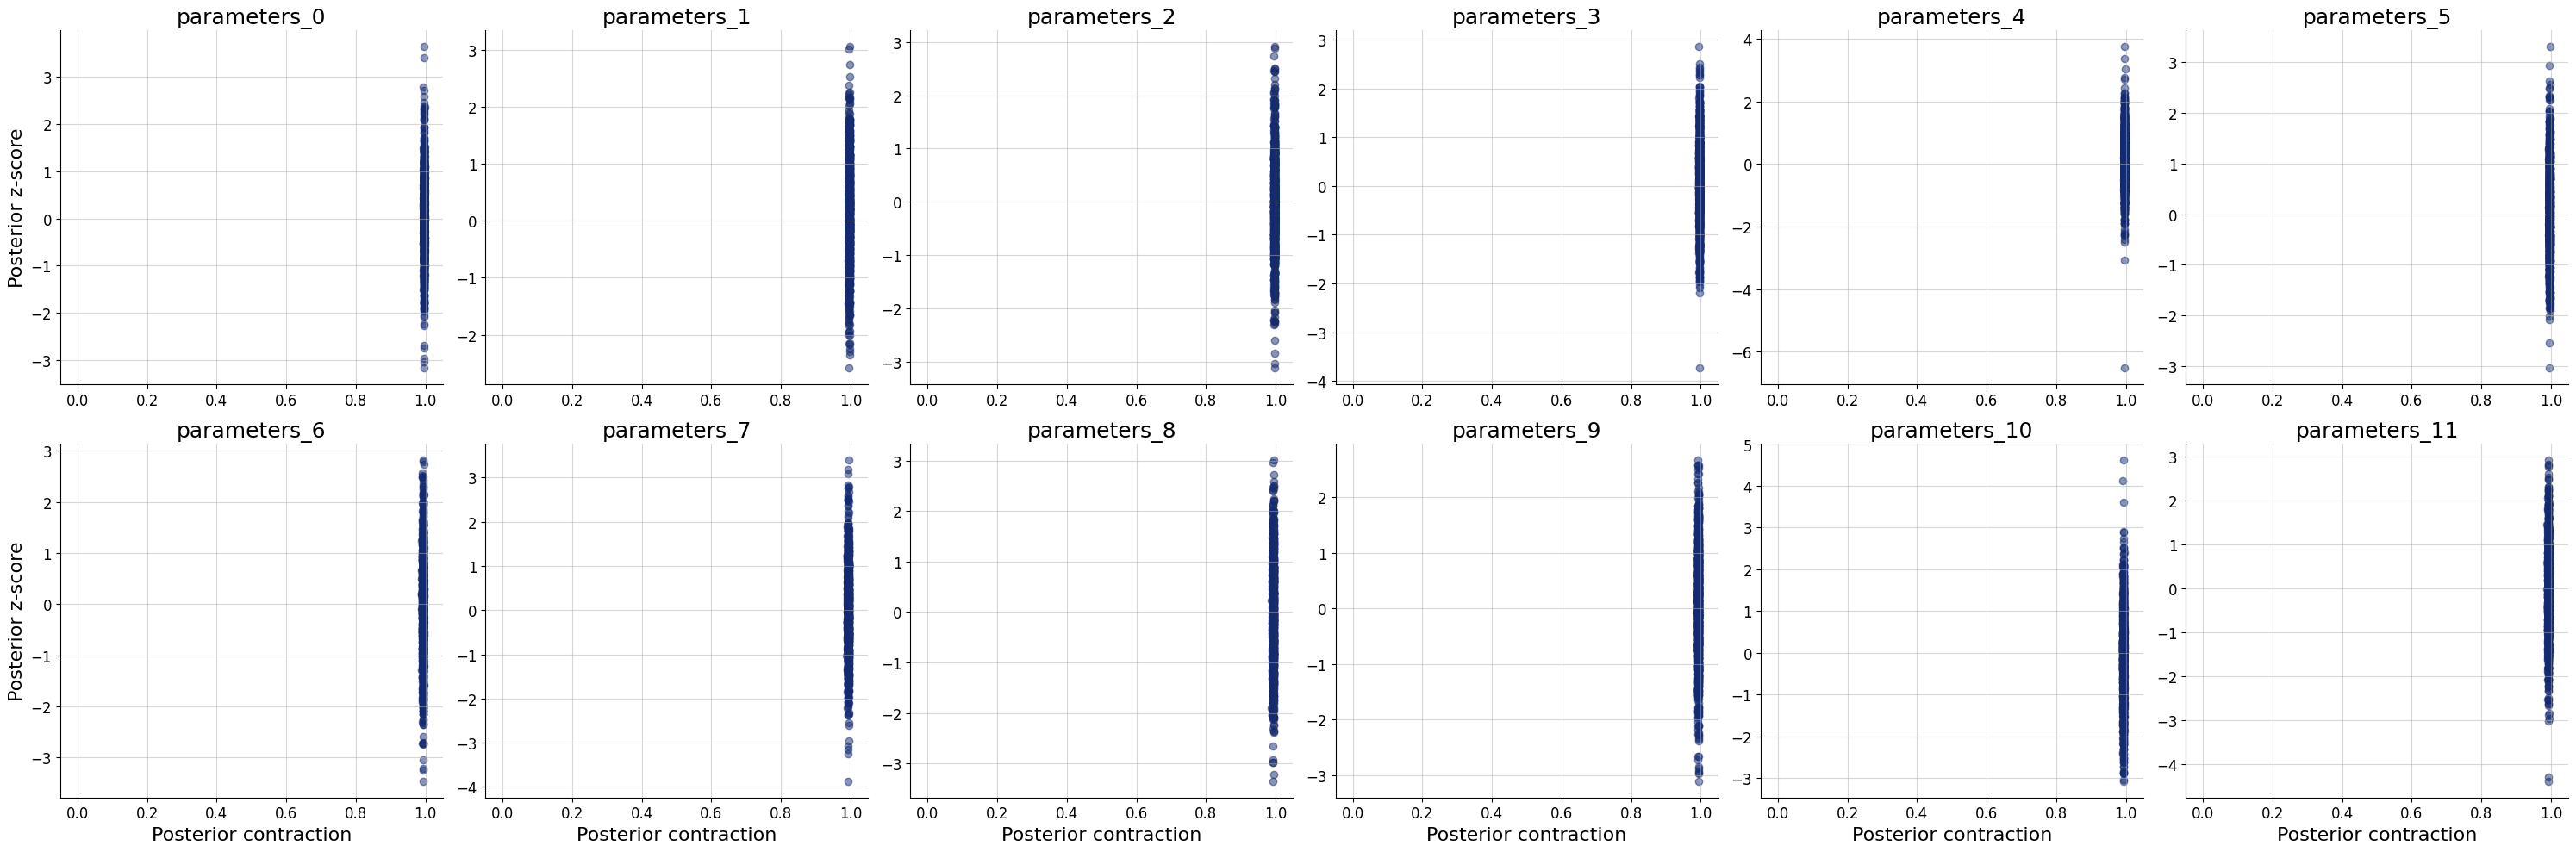

In [6]:
# Run diagnostics using held-out validation data
workflow.plot_default_diagnostics(test_data=val_data)


**Step 4: Posterior Inference with BayesFlow.**

**1. Generate a New Test Example**

This uses the same full trajectory generation logic as before (fixed masses, noisy output):

In [42]:
masses = np.random.uniform(0.5, 2.0, size=(3,))  # random masses

# Random initial conditions
init_pos = np.random.uniform(-1, 1, size=(3, 2))
init_vel = np.random.uniform(-1, 1, size=(3, 2))

# Simulate full trajectory
_, true_trajectory = simulate_3body(init_pos, init_vel, masses)

# Add Gaussian noise
noise_std = 0.05
noisy_trajectory = true_trajectory + np.random.normal(0, noise_std, size=true_trajectory.shape)

# Transpose for BayesFlow: (time_steps, features)
test_obs = noisy_trajectory.T  # Shape: (100, 12)

# Ground truth initial conditions (for evaluation)
true_init = np.concatenate([init_pos.flatten(), init_vel.flatten()])

# ✅ Add batch dimension → (1, time_steps, features)
test_input = {
    "observables": test_obs[np.newaxis, ...]
}

print("✅ Test input shape (for BayesFlow):", test_input["observables"].shape)
print("✅ True initial conditions:", true_init)

✅ Test input shape (for BayesFlow): (1, 100, 12)
✅ True initial conditions: [ 0.3119016   0.79641208 -0.22007791  0.79669132  0.78435577 -0.01003425
 -0.80119071  0.54065833  0.99680571 -0.58606675  0.14071227 -0.39522481]


**2. Use BayesFlow to Sample from Posterior**

In [43]:
posterior_samples = workflow.approximator.sample(
    num_samples=1000,
    conditions=test_input
)["parameters"]

print("✅ Posterior samples shape:", posterior_samples.shape)

✅ Posterior samples shape: (1, 1000, 12)


**3.Plot Posterior Distributions**

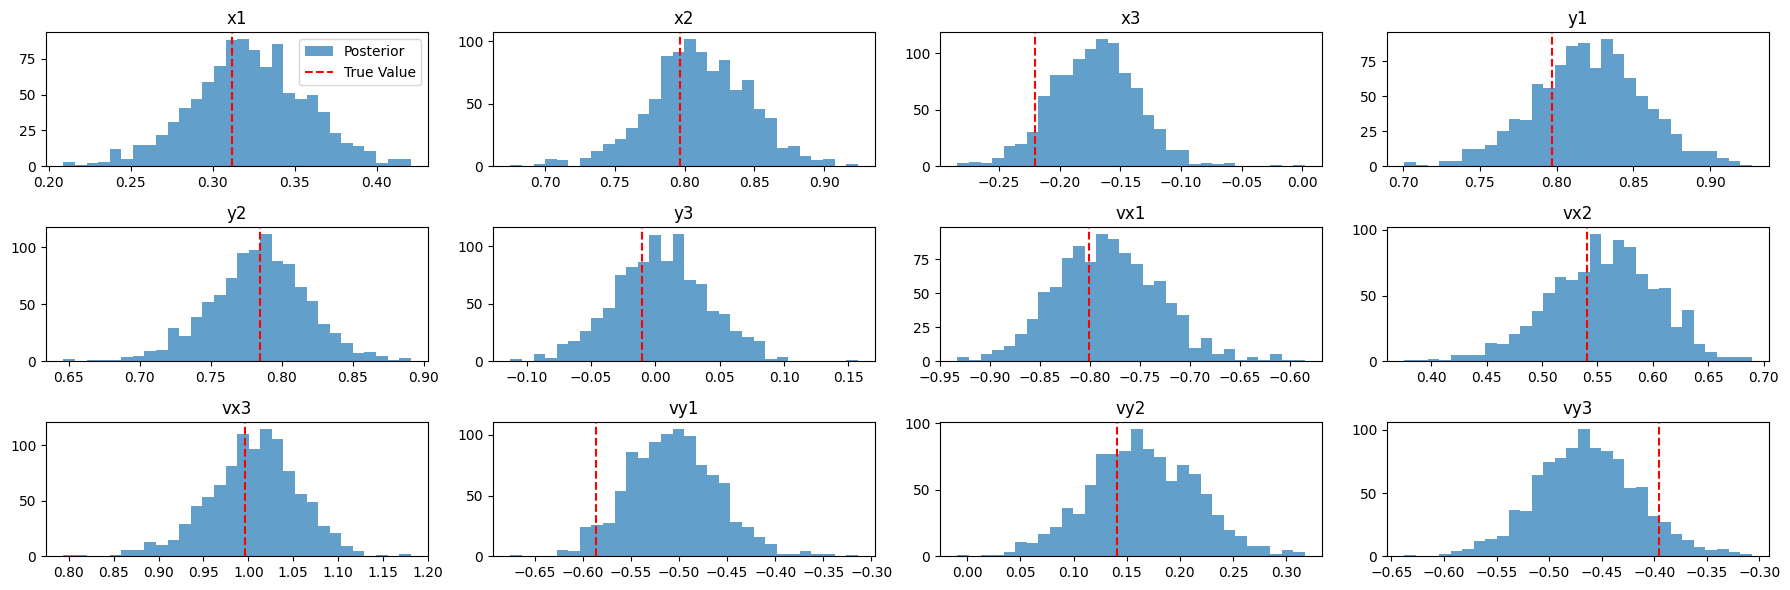

In [44]:
import matplotlib.pyplot as plt

# Remove batch dimension
posterior_samples = posterior_samples[0]

# Parameter names
param_names = [f"x{i+1}" for i in range(3)] + [f"y{i+1}" for i in range(3)] + \
              [f"vx{i+1}" for i in range(3)] + [f"vy{i+1}" for i in range(3)]

# Plot histograms
plt.figure(figsize=(18, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.hist(posterior_samples[:, i], bins=30, alpha=0.7, label="Posterior")
    plt.axvline(true_init[i], color='red', linestyle='--', label="True Value")
    plt.title(param_names[i])
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.show()


**3. Visualize the Posterior**

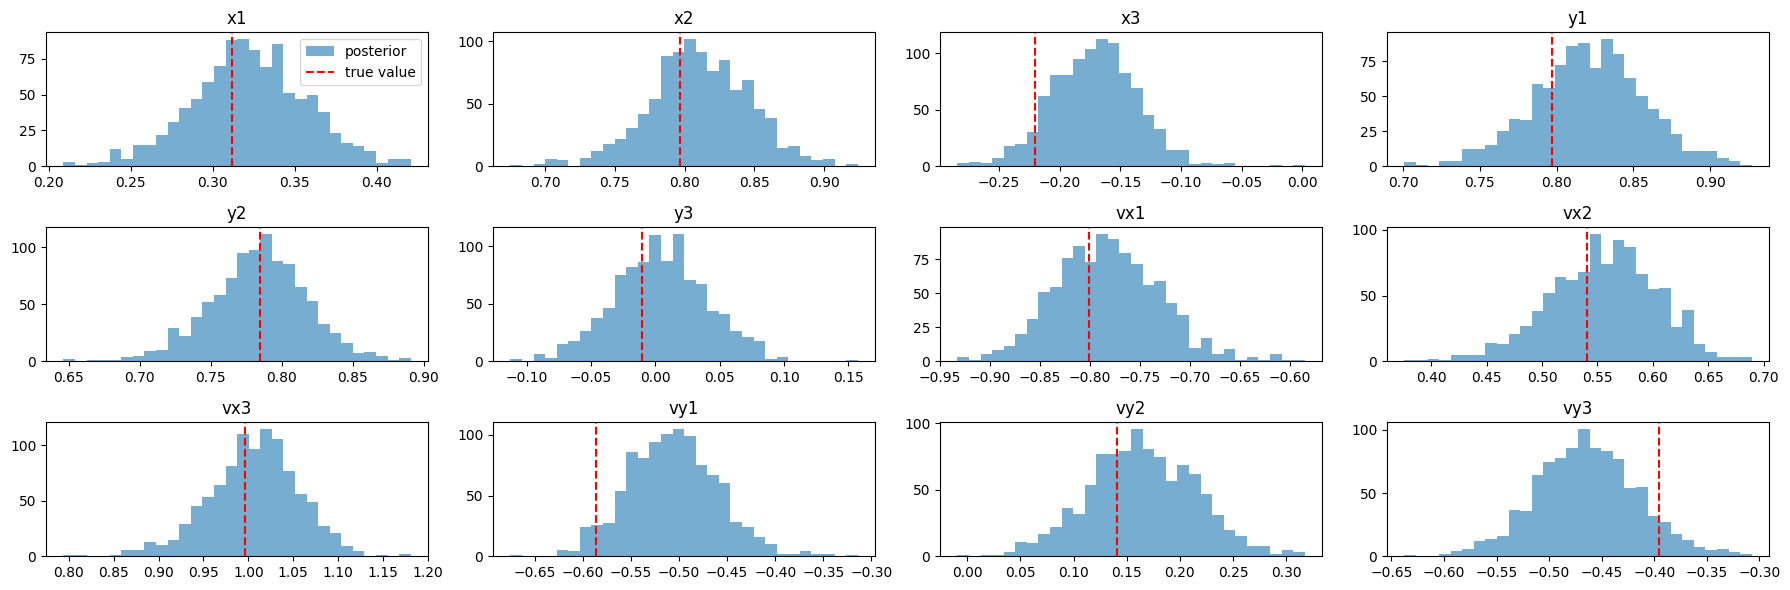

In [45]:
import matplotlib.pyplot as plt

param_names = [f"x{i+1}" for i in range(3)] + [f"y{i+1}" for i in range(3)] + \
              [f"vx{i+1}" for i in range(3)] + [f"vy{i+1}" for i in range(3)]

plt.figure(figsize=(18, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.hist(posterior_samples[:, i], bins=30, alpha=0.6, label="posterior")
    plt.axvline(true_init[i], color='red', linestyle='--', label="true value")
    plt.title(param_names[i])
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.show()


**4. Evaluate Posterior Accuracy (MAE + Coverage)**


In [46]:
import numpy as np

# Compute posterior mean
posterior_mean = np.mean(posterior_samples[0], axis=0)

# Compute MAE
mae = np.abs(posterior_mean - true_init).mean()
print(f"✅ Mean Absolute Error (MAE): {mae:.4f}")

# Compute 95% credible intervals
lower = np.percentile(posterior_samples[0], 2.5, axis=0)
upper = np.percentile(posterior_samples[0], 97.5, axis=0)

# Compute coverage
coverage = np.mean((true_init >= lower) & (true_init <= upper))
print(f"✅ 95% Credible Interval Coverage: {coverage * 100:.2f}%")


✅ Mean Absolute Error (MAE): 0.5082
✅ 95% Credible Interval Coverage: 83.33%
